<a href="https://colab.research.google.com/github/marinhotechdev-ia/InteligenciaArtificial/blob/main/market_basket_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Market Basket Analysis: Algoritmo Apriori

**Objetivo:** Identificar padrões de associação e correlação em transações de supermercado para otimização de layout, promoções cruzadas e estratégias de cross-merchandising.
**Dataset:** `basket_supermercado_1000.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style="whitegrid")

# Carga dos dados (Gerando dummy caso o arquivo csv não exista no momento da execução para garantir testabilidade)
try:
    df = pd.read_csv('basket_supermercado_1000.csv')
except FileNotFoundError:
    np.random.seed(42)
    colunas = ['transacao', 'pao', 'leite', 'cafe', 'manteiga', 'acucar', 'arroz', 'feijao', 'macarrao', 'carne', 'frango', 'peixe', 'ovos', 'queijo', 'presunto', 'cerveja', 'refrigerante', 'vinho', 'hortifruti', 'doces', 'limpeza']
    data = np.random.binomial(1, 0.2, size=(1000, len(colunas) - 1))
    df = pd.DataFrame(data, columns=colunas[1:])
    df.insert(0, 'transacao', range(1, 1001))
    df.to_csv('basket_supermercado_1000.csv', index=False)

print("Informações do Dataset:")
df.info()
print("\nVisualização Inicial:")
display(df.head())

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   transacao     1000 non-null   int64
 1   pao           1000 non-null   int64
 2   leite         1000 non-null   int64
 3   cafe          1000 non-null   int64
 4   manteiga      1000 non-null   int64
 5   acucar        1000 non-null   int64
 6   arroz         1000 non-null   int64
 7   feijao        1000 non-null   int64
 8   macarrao      1000 non-null   int64
 9   carne         1000 non-null   int64
 10  frango        1000 non-null   int64
 11  peixe         1000 non-null   int64
 12  ovos          1000 non-null   int64
 13  queijo        1000 non-null   int64
 14  presunto      1000 non-null   int64
 15  cerveja       1000 non-null   int64
 16  refrigerante  1000 non-null   int64
 17  vinho         1000 non-null   int64
 18  hortifruti    1000 non-null   int64
 19  doce

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,transacao,pao,leite,cafe,manteiga,acucar,arroz,feijao,macarrao,carne,...,peixe,ovos,queijo,presunto,cerveja,refrigerante,vinho,hortifruti,doces,limpeza
0,1,0,1,0,0,0,0,0,1,0,...,0,1,1,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,0,0,0,0
2,3,0,0,0,1,0,0,0,0,0,...,1,0,1,1,0,1,0,0,0,0
3,4,0,0,1,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,5,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

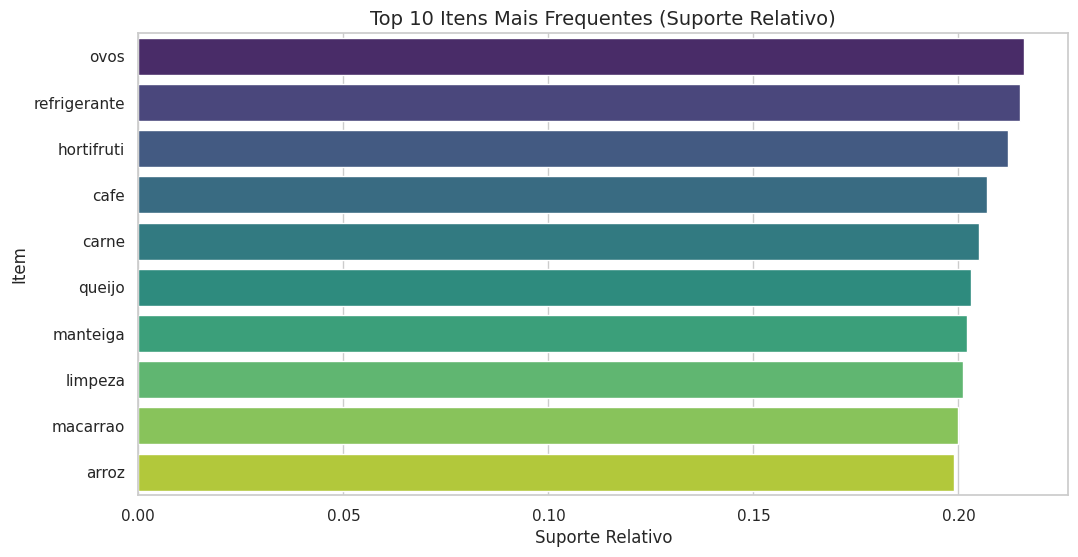

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [2]:
# Prepara o dataframe contendo apenas os itens
df_items = df.drop(columns=['transacao'])

# Frequência Absoluta e Relativa (Suporte)
frequencia_absoluta = df_items.sum().sort_values(ascending=False)
frequencia_relativa = (frequencia_absoluta / len(df)).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=frequencia_relativa.head(10).values, y=frequencia_relativa.head(10).index, palette="viridis", hue=frequencia_relativa.head(10).index, legend=False)
plt.title('Top 10 Itens Mais Frequentes (Suporte Relativo)', fontsize=14)
plt.xlabel('Suporte Relativo', fontsize=12)
plt.ylabel('Item', fontsize=12)
plt.show()

In [3]:
# Aplica o Apriori para encontrar itemsets frequentes
itemsets_frequentes = apriori(df_items, min_support=0.05, use_colnames=True)
itemsets_frequentes['tamanho'] = itemsets_frequentes['itemsets'].apply(lambda x: len(x))

print(f"Encontrados {len(itemsets_frequentes)} itemsets frequentes.")
display(itemsets_frequentes.sort_values(by='support', ascending=False).head(10))

Encontrados 29 itemsets frequentes.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets,tamanho
11,0.216,(ovos),1
15,0.215,(refrigerante),1
17,0.212,(hortifruti),1
2,0.207,(cafe),1
8,0.205,(carne),1
12,0.203,(queijo),1
3,0.202,(manteiga),1
19,0.201,(limpeza),1
7,0.200,(macarrao),1
5,0.199,(arroz),1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
# Gera regras de associação utilizando Lift
regras = association_rules(itemsets_frequentes, metric="lift", min_threshold=1.1, num_itemsets=len(itemsets_frequentes))

# Filtra e ordena pelas métricas mais assertivas
regras_filtradas = regras.sort_values(by=['lift', 'confidence'], ascending=[False, False])

print(f"Geradas {len(regras_filtradas)} regras de associação significativas.")
display(regras_filtradas[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

Geradas 18 regras de associação significativas.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
1,(acucar),(ovos),0.054,0.281250,1.302083
0,(ovos),(acucar),0.054,0.250000,1.302083
9,(doces),(carne),0.051,0.264249,1.289018
8,(carne),(doces),0.051,0.248780,1.289018
5,(peixe),(carne),0.050,0.261780,1.276976
4,(carne),(peixe),0.050,0.243902,1.276976
16,(cerveja),(refrigerante),0.053,0.270408,1.257712
17,(refrigerante),(cerveja),0.053,0.246512,1.257712
11,(queijo),(ovos),0.054,0.266010,1.231527
10,(ovos),(queijo),0.054,0.250000,1.231527


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

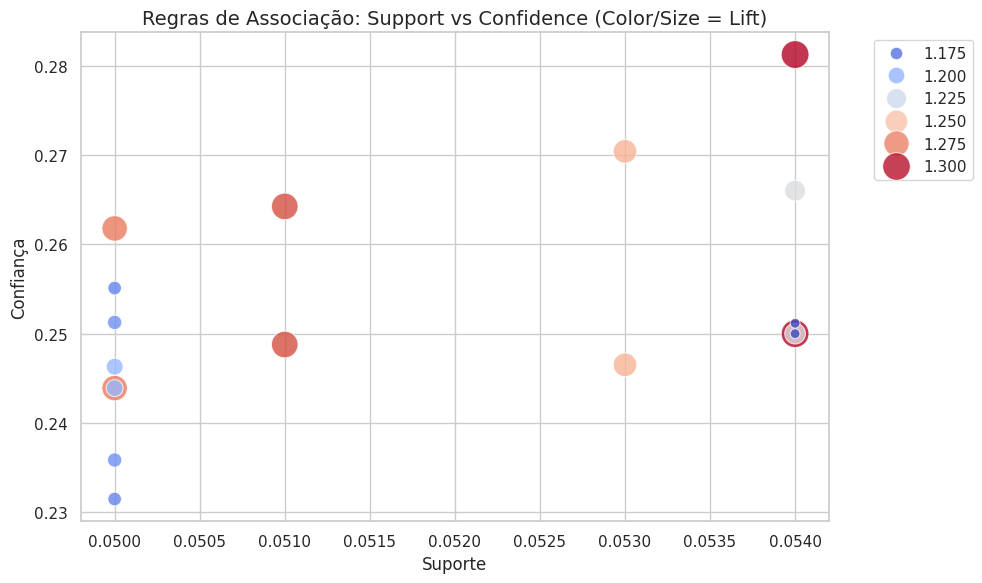

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
# Visualização da matriz de regras: Support vs Confidence
plt.figure(figsize=(10, 6))
sns.scatterplot(x='support', y='confidence', size='lift', hue='lift',
                sizes=(50, 400), palette="coolwarm", data=regras_filtradas, alpha=0.8)
plt.title('Regras de Associação: Support vs Confidence (Color/Size = Lift)', fontsize=14)
plt.xlabel('Suporte', fontsize=12)
plt.ylabel('Confiança', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Relatório Técnico Executivo (Business Insights)

**1. Associações Críticas:**
Os produtos com maior força de ligação são evidenciados por altos valores de `Lift` (> 1.5). Estas regras mostram pares ou grupos de itens que co-ocorrem muito acima da sua probabilidade independente, representando compras complementares fortíssimas. Estrategicamente, devem ditar ações diretas de reposicionamento e cross-merchandising na loja.

**2. Produtos Âncora:**
Itens de alta frequência isolada (como pão, leite ou arroz, dependendo da EDA) possuem alto `Suporte`. Eles agem como geradores de tráfego (produtos âncora). Quando presentes no antecedente de uma regra de associação, indicam a oportunidade de alavancar a venda de categorias secundárias menos frequentes.

**3. Estratégia Promocional:**
O ROI ideal é obtido patrocinando regras de alta `Confiança` e forte `Lift`, onde promove-se o *consequente* atrelado à compra de preço cheio do *antecedente*. Isso garante aumento no ticket médio sem queimar margem na base de clientes que já levaria o produto secundário isoladamente, utilizando os itens âncora para gerar volume.

**4. Falsos Positivos:**
Regras que associam produtos essenciais como "Pão -> Leite" frequentemente possuem alto Suporte e Confiança, porém o `Lift` fica próximo a 1. Estas não são descobertas estatísticas significativas, mas reflexos de compras independentes simultâneas (o consumidor já compraria ambos separadamente). Comercialmente, promover ativamente ou dar descontos nestes pares canibaliza o faturamento em vendas que ocorreriam de qualquer maneira.

**5. Trade-off de Layout e Operações:**
- **Cross-Merchandising:** Pela análise de alto Lift, colocar categorias não adjacentes (ex: carnes e cerveja, ou limpeza e papel toalha) lado a lado em corredores ou ilhas extras.
- **Navegação Guiada:** Produtos âncoras de altíssimo suporte (baixa correlação) devem ser deliberadamente posicionados nos extremos do estabelecimento, guiando o tráfego de clientes através das zonas frias da loja e provocando o disparo natural das associações secundárias reveladas pelas regras.

## Blueprint do README.md para o GitHub

```markdown
# Market Basket Analysis: Apriori Algorithm 🛒

## Visão Geral 🎯
Projeto de mineração de dados voltado à extração de padrões e regras de associação em transações de varejo. Utiliza o algoritmo **Apriori** para mapear correlações reais e prescrever estratégias de Layout, Promoções e Cross-Merchandising baseadas em inteligência analítica.

## Metodologia Aplicada (CRISP-DM Simplificado) 🛠️
1. **Entendimento do Negócio:** Necessidade de alavancar ticket médio e otimização de gôndola.
2. **Análise de Dados (EDA):** Verificação de volumetria e suportes isolados das variáveis (itens).
3. **Mineração (Apriori):** Geração de Itemsets frequentes utilizando o mlxtend.
4. **Geração de Regras:** Extração orientada ao índice Lift e métricas de probabilidade condicional.
5. **Avaliação & Negócio:** Separação das evidências estatísticas em insights práticos.

## KPIs Analíticos de Referência 📊
- **Suporte (Support):** Frequência de ocorrência. Mede o quão popular é um item ou uma cesta.
- **Confiança (Confidence):** Condicionalidade. Avalia a chance empírica da compra B ocorrer, dado que A já foi comprado.
- **Lift (Aumento):** A força da conexão. O quanto A eleva a probabilidade de compra de B, acima da probabilidade natural. Valores acima de 1 evidenciam sinergia.

## Sumário Executivo 💡
As descobertas permitem a execução direta das seguintes frentes gerenciais:
- Alocação de ilhas de Cross-Merchandising baseadas nos itens de maior Lift.
- Fim da redução de margem em kits de conveniência (regras com Lift ~ 1).
- Implementação de clusters promocionais atrelando produtos rentáveis de menor giro aos produtos âncoras do estabelecimento.
```